In [72]:
import pandas as pd

df = pd.read_csv('/content/Country-data.csv')
display(df.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [74]:
display(df.describe())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [75]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


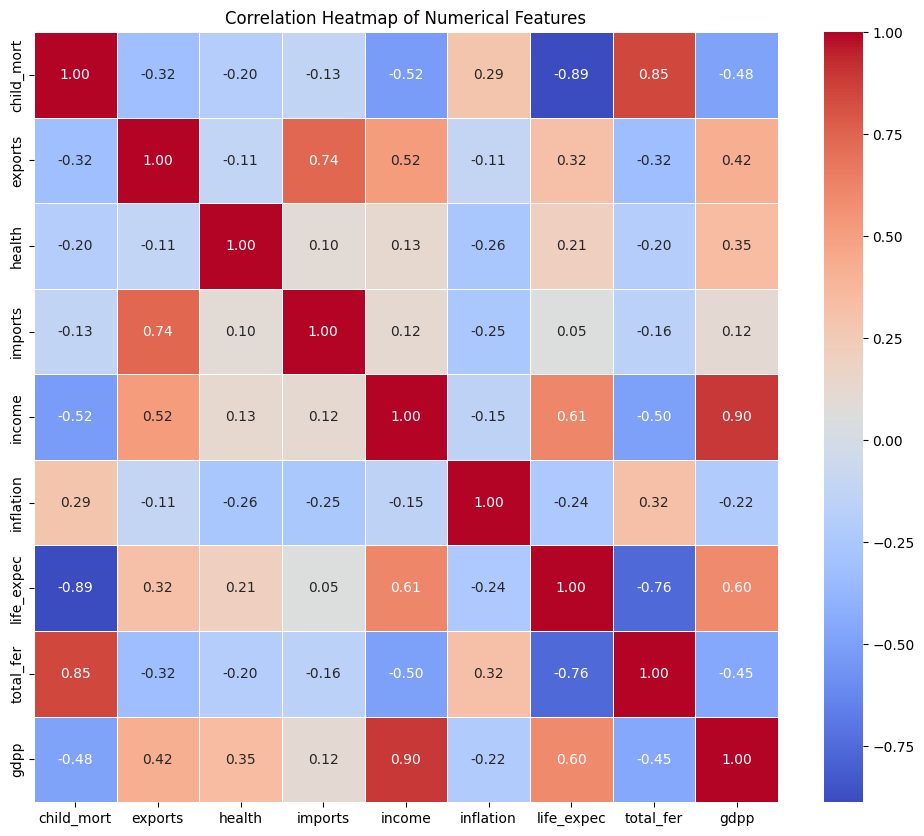

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [77]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling, excluding 'country'
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

# Initialize the StandardScaler
scaler = StandardScaler()

# Create a copy of the DataFrame to store scaled data
df_scaled = df.copy()

# Apply scaling to the numerical columns
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print("DataFrame after feature scaling (first 5 rows of scaled numerical features):")
display(df_scaled.head())

DataFrame after feature scaling (first 5 rows of scaled numerical features):


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,Albania,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,Algeria,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,Angola,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,Antigua and Barbuda,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [78]:
# Define quantiles for categorization
low_gdpp_threshold = df['gdpp'].quantile(0.33)
medium_gdpp_threshold = df['gdpp'].quantile(0.66)

# Create a new 'gdpp_category' column in the scaled DataFrame
def categorize_gdpp(gdpp_value):
    if gdpp_value <= low_gdpp_threshold:
        return 'Low GDP'
    elif gdpp_value <= medium_gdpp_threshold:
        return 'Medium GDP'
    else:
        return 'High GDP'

df_scaled['gdpp_category'] = df['gdpp'].apply(categorize_gdpp)

print("Distribution of the new 'gdpp_category' target variable:")
display(df_scaled['gdpp_category'].value_counts())

# Now, let's look at the first few rows of the updated df_scaled
print("\nDataFrame after adding 'gdpp_category':")
display(df_scaled.head())

Distribution of the new 'gdpp_category' target variable:


,count
gdpp_category,
High GDP,57
Low GDP,55
Medium GDP,55



DataFrame after adding 'gdpp_category':


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,gdpp_category
0,Afghanistan,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180,Low GDP
1,Albania,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623,Medium GDP
2,Algeria,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376,Medium GDP
3,Angola,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268,Medium GDP
4,Antigua and Barbuda,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817,High GDP


In [79]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Ensure pandas is imported for Series.value_counts

# Separate features (X) and target (y)
# Drop 'country' and 'gdpp' (original continuous) as they are not features for classification, and 'gdpp_category' is the target
X = df_scaled.drop(columns=['country', 'gdpp', 'gdpp_category'])
y = df_scaled['gdpp_category']

# Encode the target variable into numerical labels for XGBoost
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Distribution of target in y_train:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"Distribution of target in y_test:\n{pd.Series(y_test).value_counts(normalize=True)}")

# Store the label encoder classes for later use (e.g., in confusion matrix display)
encoded_classes = label_encoder.classes_

Shape of X_train: (133, 8)
Shape of X_test: (34, 8)
Distribution of target in y_train:
0    0.338346
1    0.330827
2    0.330827
Name: proportion, dtype: float64
Distribution of target in y_test:
0    0.352941
1    0.323529
2    0.323529
Name: proportion, dtype: float64


In [80]:
# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [81]:
# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")
print("\nRandom Forest Classification Report:")
print(report_rf)

Random Forest Classifier Accuracy: 0.9118

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       1.00      0.82      0.90        11
           2       0.79      1.00      0.88        11

    accuracy                           0.91        34
   macro avg       0.93      0.91      0.91        34
weighted avg       0.93      0.91      0.91        34



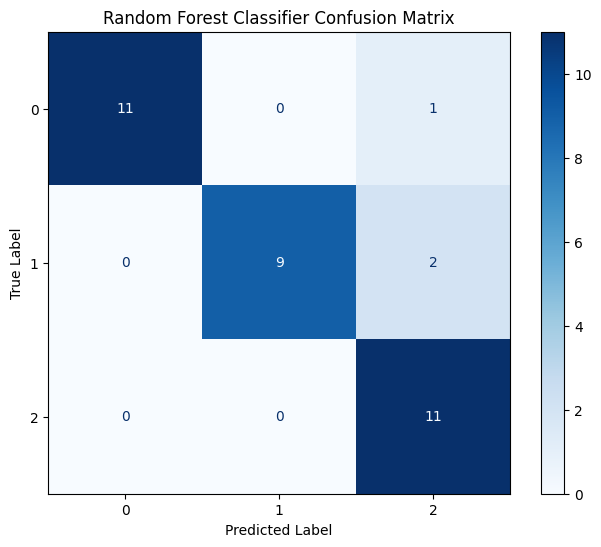

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_classifier.classes_)

# Create a ConfusionMatrixDisplay object
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_classifier.classes_)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Random Forest Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False) # Remove grid for cleaner confusion matrix
plt.show()

Feature Importances (Top 10):


,Feature,Importance
4,income,0.342526
0,child_mort,0.180047
6,life_expec,0.139171
7,total_fer,0.093154
5,inflation,0.077130
1,exports,0.069978
2,health,0.056704
3,imports,0.041291


/tmp/ipykernel_17912/2967246237.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


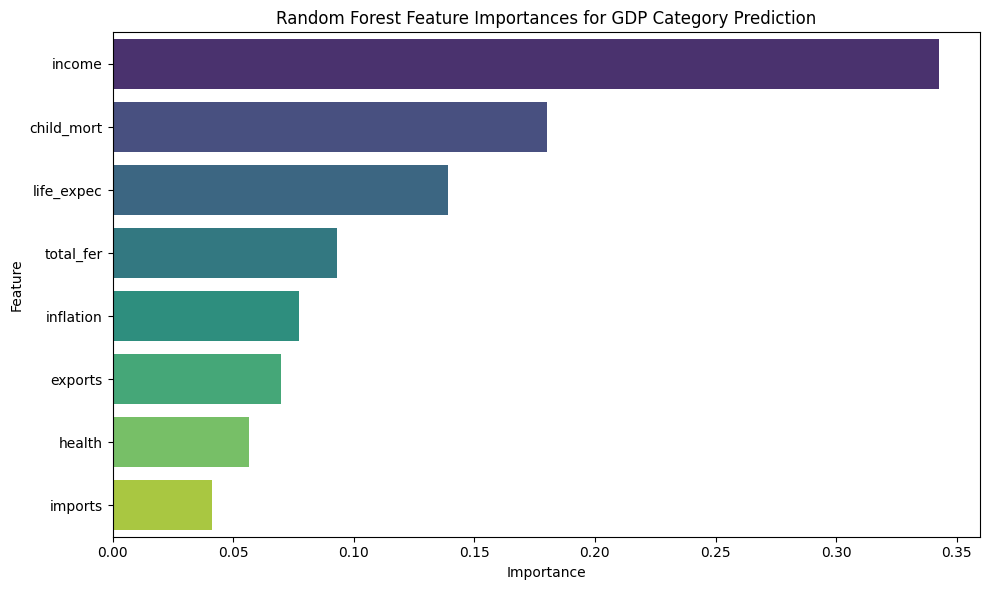

In [83]:
importances = rf_classifier.feature_importances_
features = X.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importances (Top 10):")
display(feature_importance_df.head(10))

# Plotting feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importances for GDP Category Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Training an XGBoost Classifier

Now, let's train an XGBoost classifier to predict the `gdpp_category`. XGBoost (eXtreme Gradient Boosting) is known for its speed and performance. We will use the same training and testing data split as before.

In [84]:
import xgboost as xgb

# Initialize and train the XGBoost Classifier
xgb_classifier = xgb.XGBClassifier(
    objective='multi:softmax', # For multi-class classification
    num_class=len(encoded_classes), # Number of unique classes
    eval_metric='mlogloss',    # Evaluation metric for multi-class
    use_label_encoder=False,   # Suppress warning for label encoding
    random_state=42
)

xgb_classifier.fit(X_train, y_train)

print("XGBoost Classifier trained successfully!")

XGBoost Classifier trained successfully!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:39:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [85]:
# Make predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
report_xgb = classification_report(y_test, y_pred_xgb, target_names=encoded_classes)

print(f"XGBoost Classifier Accuracy: {accuracy_xgb:.4f}")
print("\nXGBoost Classification Report:")
print(report_xgb)

XGBoost Classifier Accuracy: 0.9118

XGBoost Classification Report:
              precision    recall  f1-score   support

    High GDP       1.00      1.00      1.00        12
     Low GDP       1.00      0.73      0.84        11
  Medium GDP       0.79      1.00      0.88        11

    accuracy                           0.91        34
   macro avg       0.93      0.91      0.91        34
weighted avg       0.93      0.91      0.91        34



### Visualizing XGBoost Classifier Results: Confusion Matrix

Let's also plot the confusion matrix for the XGBoost model to see its performance visually and compare it with the Random Forest model.

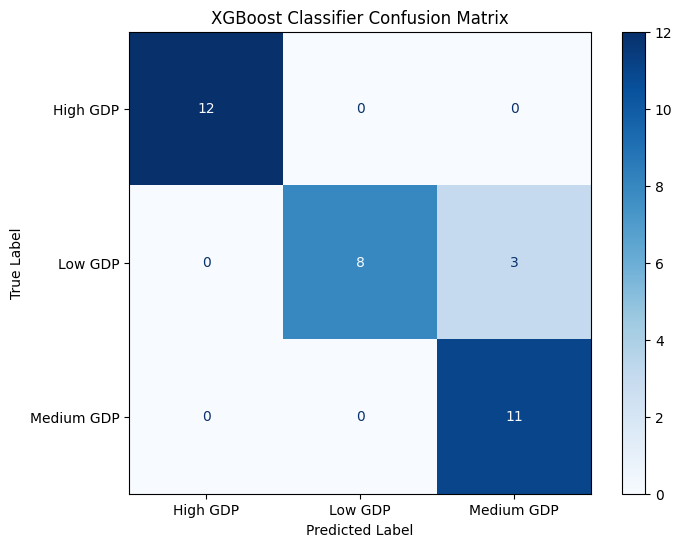

In [86]:
# Compute the confusion matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=xgb_classifier.classes_)

# Create a ConfusionMatrixDisplay object, using the original class names
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=encoded_classes)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp_xgb.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('XGBoost Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False) # Remove grid for cleaner confusion matrix
plt.show()

### Feature Importance from XGBoost Classifier

Similar to the Random Forest, let's examine the feature importances from the XGBoost classifier to understand which features it considers most relevant for predicting GDP categories.

XGBoost Feature Importances (Top 10):


,Feature,Importance
4,income,0.653367
0,child_mort,0.095208
6,life_expec,0.059643
3,imports,0.054879
5,inflation,0.044231
2,health,0.033550
7,total_fer,0.032819
1,exports,0.026305


/tmp/ipykernel_17912/1948144242.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb, palette='viridis')


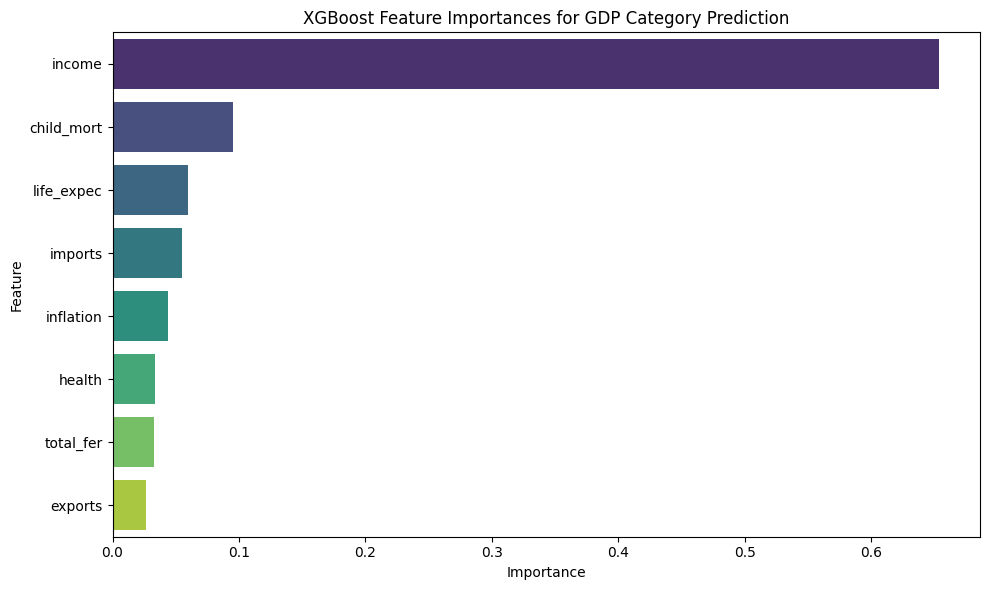

In [87]:
# Get feature importances from XGBoost
importances_xgb = xgb_classifier.feature_importances_
features_xgb = X.columns

# Create a DataFrame for better visualization
feature_importance_df_xgb = pd.DataFrame({
    'Feature': features_xgb,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)

print("XGBoost Feature Importances (Top 10):")
display(feature_importance_df_xgb.head(10))

# Plotting feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb, palette='viridis')
plt.title('XGBoost Feature Importances for GDP Category Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

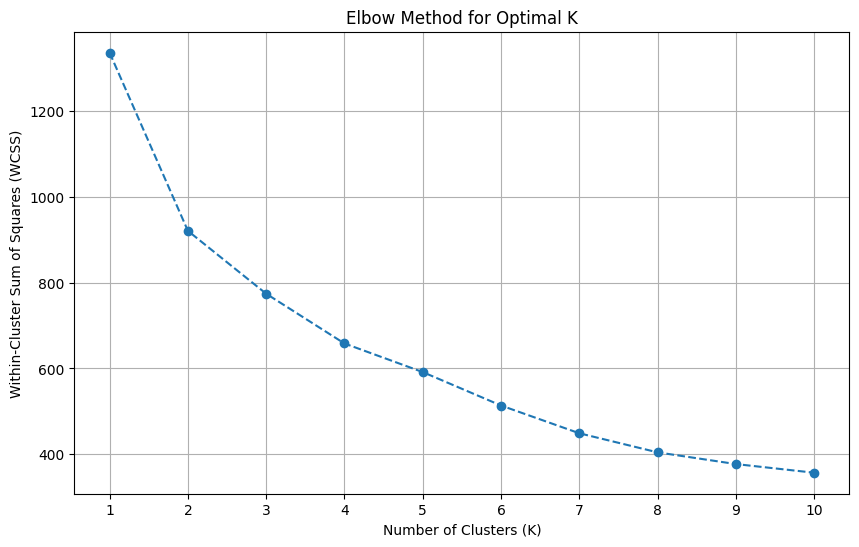

In [88]:
from sklearn.cluster import KMeans

# We will use the scaled data without the target variable for clustering
X_cluster = df_scaled.drop(columns=['country', 'gdpp', 'gdpp_category'])

wcss = []
max_k = 10 # Let's test up to 10 clusters

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

Based on the Elbow Method plot, we need to choose an optimal `K`. For demonstration, let's assume `K=3` (which often aligns with the Low/Medium/High GDP categories we created earlier, but in a real scenario, this would be determined visually from the plot or with other metrics like silhouette score).

In [89]:
# Apply K-Means clustering with the chosen number of clusters
k = 3 # Optimal number of clusters based on the elbow method (example choice)
kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
df_scaled['kmeans_cluster'] = kmeans.fit_predict(X_cluster)

print(f"K-Means clustering applied with {k} clusters.")
print("Distribution of countries across clusters:")
display(df_scaled['kmeans_cluster'].value_counts().sort_index())

K-Means clustering applied with 3 clusters.
Distribution of countries across clusters:


,count
kmeans_cluster,
0,54
1,110
2,3


### Visualizing K-Means Clusters with PCA

To visualize the clusters, we'll reduce the dimensionality of our data using Principal Component Analysis (PCA) to 2 components. This allows us to plot the clusters on a 2D scatter plot.

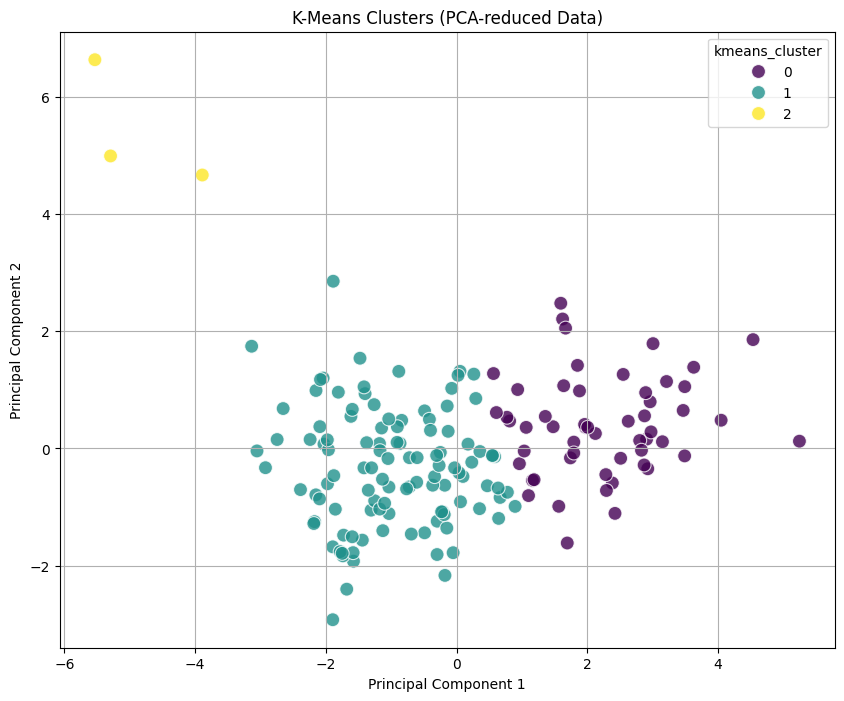

In [90]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['principal_component_1', 'principal_component_2'])
pca_df['kmeans_cluster'] = df_scaled['kmeans_cluster']
pca_df['gdpp_category'] = df_scaled['gdpp_category'] # Add original GDP category for comparison

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='kmeans_cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('K-Means Clusters (PCA-reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Analyzing K-Means Cluster Characteristics

Let's analyze the characteristics of each cluster by looking at the mean values of the original features for each cluster. This helps us understand what defines each group of countries.

In [91]:
# Add the cluster assignments to the original (unscaled) DataFrame for easier interpretation
df_original_with_clusters = df.copy()
df_original_with_clusters['kmeans_cluster'] = df_scaled['kmeans_cluster']
df_original_with_clusters['gdpp_category'] = df_scaled['gdpp_category']

# Calculate the mean of each feature for each cluster
cluster_means = df_original_with_clusters.groupby('kmeans_cluster')[X.columns].mean()

print("Mean Feature Values for Each K-Means Cluster:")
display(cluster_means)

# You can also compare these clusters with the original 'gdpp_category'
print("Distribution of original GDP categories within each K-Means cluster:")
display(pd.crosstab(df_original_with_clusters['kmeans_cluster'], df_original_with_clusters['gdpp_category']))

Mean Feature Values for Each K-Means Cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer
kmeans_cluster,,,,,,,,
0,86.577778,28.887019,6.236111,42.628998,3888.203704,12.169907,60.066667,4.757222
1,15.486364,43.430000,7.100818,45.988182,22373.636364,5.772609,75.408182,2.102545
2,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000


Distribution of original GDP categories within each K-Means cluster:


gdpp_category,High GDP,Low GDP,Medium GDP
kmeans_cluster,,,
0,1,45,8
1,53,10,47
2,3,0,0


In [92]:
from sklearn.cluster import DBSCAN

# Instantiate and fit DBSCAN
# We'll start with some default or empirically chosen values for eps and min_samples.
# A common rule of thumb for min_samples is 2 * number_of_features
# eps needs to be chosen carefully, often using a k-distance plot

dbscan = DBSCAN(eps=1.5, min_samples=2 * X_cluster.shape[1]) # Example values
df_scaled['dbscan_cluster'] = dbscan.fit_predict(X_cluster)

print("DBSCAN clustering applied.")
print("Distribution of countries across DBSCAN clusters:")
display(df_scaled['dbscan_cluster'].value_counts().sort_index())

# Noise points are labeled as -1

DBSCAN clustering applied.
Distribution of countries across DBSCAN clusters:


,count
dbscan_cluster,
-1,65
0,102


### Visualizing DBSCAN Clusters with PCA

Similar to K-Means, we'll use PCA to reduce the dimensionality to 2 components and visualize the DBSCAN clusters. Noise points (labeled -1 by DBSCAN) will appear as separate points.

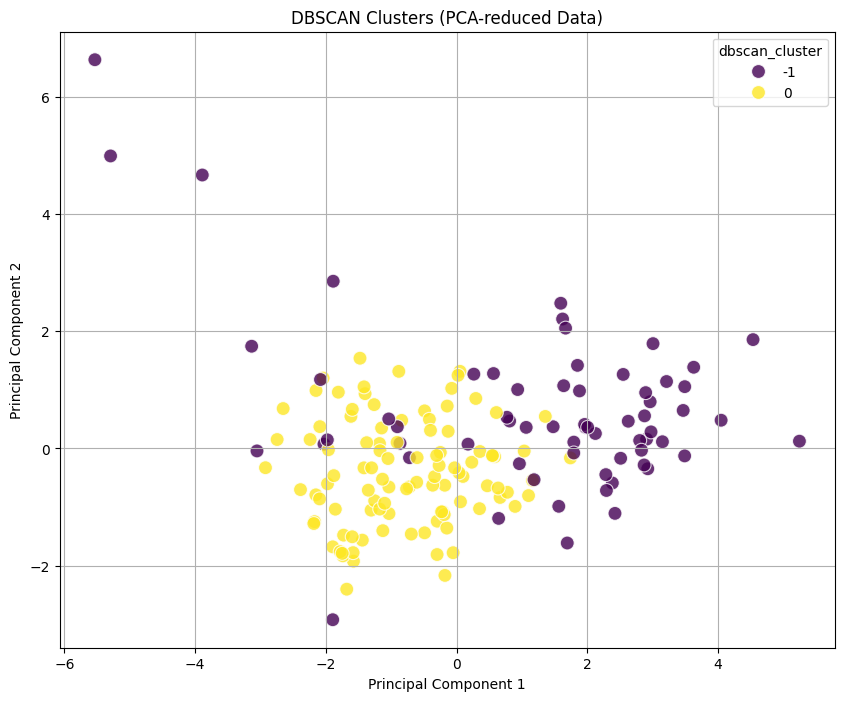

In [93]:
# Add DBSCAN cluster assignments to the PCA DataFrame
pca_df['dbscan_cluster'] = df_scaled['dbscan_cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='dbscan_cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('DBSCAN Clusters (PCA-reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [94]:
# Add the DBSCAN cluster assignments to the original (unscaled) DataFrame
df_original_with_clusters['dbscan_cluster'] = df_scaled['dbscan_cluster']

# Calculate the mean of each feature for each DBSCAN cluster
dbscan_cluster_means = df_original_with_clusters.groupby('dbscan_cluster')[X.columns].mean()

print("Mean Feature Values for Each DBSCAN Cluster:")
display(dbscan_cluster_means)

print("Distribution of original GDP categories within each DBSCAN cluster:")
display(pd.crosstab(df_original_with_clusters['dbscan_cluster'], df_original_with_clusters['gdpp_category']))

# Identify countries labeled as noise by DBSCAN (-1 cluster)
noise_countries = df_original_with_clusters[df_original_with_clusters['dbscan_cluster'] == -1]
if not noise_countries.empty:
    print("\nCountries identified as noise (Cluster -1):")
    display(noise_countries[['country', 'gdpp_category']])
else:
    print("\nNo noise points identified by DBSCAN with the current parameters.")

Mean Feature Values for Each DBSCAN Cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer
dbscan_cluster,,,,,,,,
-1,70.833846,42.612600,6.354769,49.357937,15262.046154,11.774908,63.749231,4.211231
0,17.518627,40.150784,7.109412,45.317647,18344.411765,5.237225,74.893137,2.142941


Distribution of original GDP categories within each DBSCAN cluster:


gdpp_category,High GDP,Low GDP,Medium GDP
dbscan_cluster,,,
-1,15,41,9
0,42,14,46



Countries identified as noise (Cluster -1):


,country,gdpp_category
0,Afghanistan,Low GDP
3,Angola,Medium GDP
17,Benin,Low GDP
21,Botswana,Medium GDP
23,Brunei,High GDP
...,...,...
157,United Arab Emirates,High GDP
159,United States,High GDP
163,Venezuela,High GDP
165,Yemen,Low GDP
